TREINO do StandardScaler.
Classes do Alvo encontradas (em MAIÚSCULAS): ['HIGH', 'LOW', 'MEDIUM', 'NONE', 'VERY_HIGH']
TESTE - Aplica o StandardScaler já treinado.
Shape final do Treino (X_train): (6812, 33)
Shape final do Teste (X_test):  (1500, 33)
Número de features: 33
A calcular o Cross-Validation do Stack (MLP + StandardScaler)...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.7min finished



Validação concluída em 1.67 minutos.
Score ANTERIOR (v16, 2 modelos, MinMaxScaler): 0.81489 (Kaggle: 0.83555)
Score ANTERIOR (v46, 3 modelos, MinMaxScaler): 0.81665 (Kaggle: 0.82666)
MELHOR ACCURACY (Stacking v48, 3 modelos, StandardScaler): 0.81386

--- [FIM DO PIPELINE] ---
Ficheiro 'submission_v48_STACKING_MLP_StandardScaler.csv' criado com sucesso!
   RowId Speed_Diff
0      1       None
1      2        Low
2      3       None
3      4       High
4      5        Low

   RELATÓRIO DETALHADO E VISUALIZAÇÃO (STACKING MLP + STANDARDSCALER)
[SUCESSO] Imagem 'matriz_confusao_mlp_std_laranja.png' guardada.

--- Métricas de Classificação (Validação Cruzada) ---
              precision  recall  f1-score  support
HIGH          0.783      0.781   0.782     1063   
LOW           0.717      0.723   0.720     1419   
MEDIUM        0.789      0.786   0.787     1651   
NONE          0.898      0.909   0.903     2200   
VERY_HIGH     0.871      0.816   0.843      479   
accuracy      0.814      0.

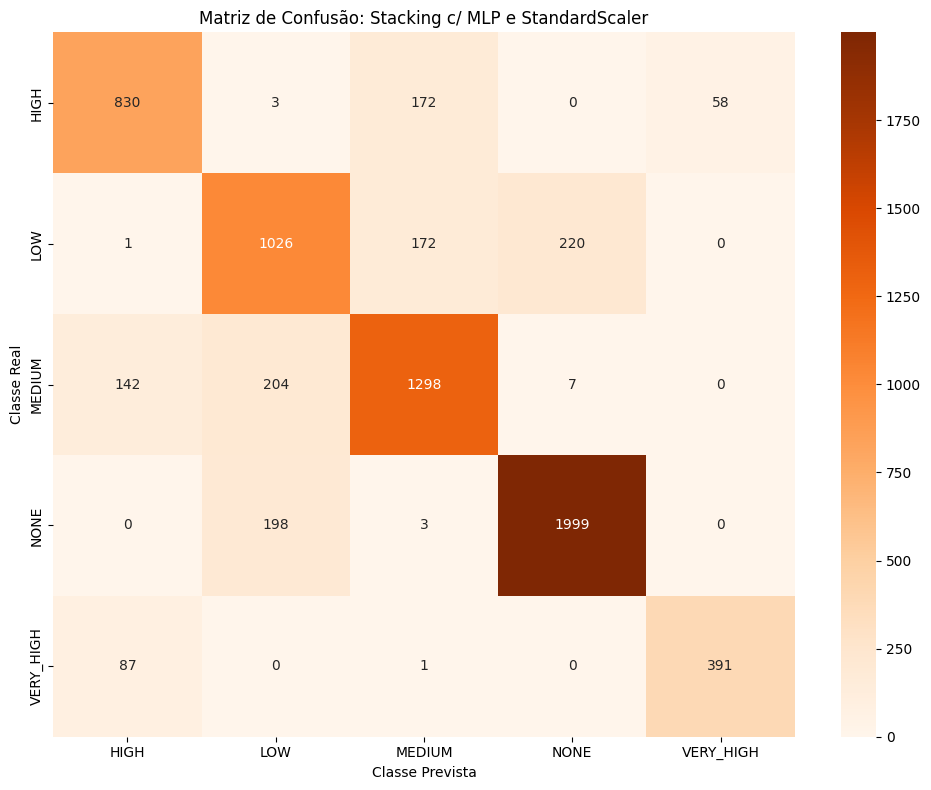

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier 
from sklearn.model_selection import cross_val_score
import warnings
import time 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')
warnings.filterwarnings('ignore', category=Warning) 

# --- 1. FUNÇÃO DE PRÉ-PROCESSAMENTO (COM StandardScaler) ---
def formatar_celula(series_coluna):
    s = series_coluna.astype(str).replace('NULL', pd.NA)
    s = s.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
    s = s.str.upper()
    s = s.str.replace(r'[^A-Z0-9]+', '_', regex=True)
    s = s.str.strip('_')
    s = s.replace('', pd.NA)
    return s

def preprocessar_dados(df, colunas_scaler_treinadas=None, scaler=None):
    if 'RowId' not in df.columns and 'AVERAGE_SPEED_DIFF' not in df.columns:
        df_final_row_ids = np.arange(1, len(df) + 1)
    else:
        df_final_row_ids = None

    cols_to_transform = ['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN']
    for col in cols_to_transform:
        if col in df.columns:
            df[col] = formatar_celula(df[col])

    cols_to_drop_base = ['city_name', 'AVERAGE_RAIN', 'AVERAGE_PRECIPITATION', 'record_date']
    
    try:
        df['record_date_dt'] = pd.to_datetime(df['record_date'], format='mixed', dayfirst=True)
        df['Hora_sin'] = np.sin(2 * np.pi * df['record_date_dt'].dt.hour/24)
        df['Hora_cos'] = np.cos(2 * np.pi * df['record_date_dt'].dt.hour/24)
        df['Mes_sin'] = np.sin(2 * np.pi * df['record_date_dt'].dt.month/12)
        df['Mes_cos'] = np.cos(2 * np.pi * df['record_date_dt'].dt.month/12)
        df['DIA_SEMANA'] = df['record_date_dt'].dt.dayofweek
        df['IS_WEEKEND'] = df['DIA_SEMANA'].isin([5, 6]).astype(int)
        rush_hours = [7, 8, 9, 17, 18, 19]
        df['IS_RUSH_HOUR'] = df['record_date_dt'].dt.hour.isin(rush_hours).astype(int)
        df = df.drop(columns=['record_date_dt'])
    except KeyError:
        pass

    cols_existentes_drop = [col for col in cols_to_drop_base if col in df.columns]
    df = df.drop(columns=cols_existentes_drop)

    if 'AVERAGE_CLOUDINESS' in df.columns:
        df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].replace('NAN', np.nan)
        df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].fillna('NONE')

    cols_to_onehot = ['LUMINOSITY', 'AVERAGE_CLOUDINESS', 'DIA_SEMANA']
    for col in cols_to_onehot:
        if col in df.columns:
            prefix = col[:3].upper()
            if col == 'DIA_SEMANA': prefix = 'DAY'
            dummies = pd.get_dummies(df[col], prefix=prefix, dtype=int, sparse=False)
            df = pd.concat([df, dummies], axis=1)
            df = df.drop(col, axis=1)

    cols_to_normalize = [
        'AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF', 'AVERAGE_FREE_FLOW_TIME',
        'AVERAGE_TEMPERATURE', 'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY',
        'AVERAGE_WIND_SPEED', 'IS_WEEKEND', 'IS_RUSH_HOUR',
        'Hora_sin', 'Hora_cos', 'Mes_sin', 'Mes_cos'
    ]
    cols_existentes_normalize = [col for col in cols_to_normalize if col in df.columns]
    
    if scaler is None:
        print("TREINO do StandardScaler.")
        scaler = StandardScaler()
        if cols_existentes_normalize:
            df[cols_existentes_normalize] = scaler.fit_transform(df[cols_existentes_normalize])
        return df, scaler, cols_existentes_normalize, df_final_row_ids
    else:
        print("TESTE - Aplica o StandardScaler já treinado.")
        cols_para_scaler_teste = [col for col in colunas_scaler_treinadas if col in df.columns]
        if cols_para_scaler_teste:
            df[cols_para_scaler_teste] = scaler.transform(df[cols_para_scaler_teste])
        return df, None, None, df_final_row_ids


# --- 2. CARREGAR DADOS ---
df_train = pd.read_csv("training_data.csv", delimiter=",", encoding="latin-1")
df_test = pd.read_csv("test_data.csv", delimiter=",", encoding="latin-1")
y_train_raw = df_train.pop('AVERAGE_SPEED_DIFF')
test_row_ids = np.arange(1, len(df_test) + 1)


# --- 3. PRÉ-PROCESSAMENTO (TREINO) ---
X_train, scaler, colunas_scaler, _ = preprocessar_dados(df_train)
le = LabelEncoder()
y_train_formatado = formatar_celula(y_train_raw).replace('NAN', 'NONE').fillna('NONE')
y_train_encoded = le.fit_transform(y_train_formatado)
print(f"Classes do Alvo encontradas (em MAIÚSCULAS): {list(le.classes_)}")


# --- 4. PRÉ-PROCESSAMENTO (TESTE) ---
X_test, _, _, _ = preprocessar_dados(df_test, colunas_scaler_treinadas=colunas_scaler, scaler=scaler)


# --- 5. ALINHAMENTO DE COLUNAS ---
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_train = X_train.reindex(columns=X_test.columns, fill_value=0)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)
print(f"Shape final do Treino (X_train): {X_train.shape}")
print(f"Shape final do Teste (X_test):  {X_test.shape}")
print(f"Número de features: {X_train.shape[1]}") # 33


# --- 6. VALIDAÇÃO DO ENSEMBLE ---

# Modelos de Base (Nível 0)
estimators = [
    ('xgb', XGBClassifier(
        learning_rate=0.08, max_depth=5, n_estimators=100,
        subsample=0.7, colsample_bytree=0.9,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    )),
    ('lgbm', LGBMClassifier(
        subsample=0.9, num_leaves=50, n_estimators=200,
        learning_rate=0.01, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(64, 32), 
        activation='relu',           
        solver='adam',               
        max_iter=500,                
        random_state=42,
        early_stopping=True          
    ))
]

# Meta-Modelo (Nível 1) - LR (v16)
meta_model = LogisticRegression(random_state=42, n_jobs=-1)

# Criar o Stack
stack_clf_mlp_std = StackingClassifier(
    estimators=estimators, 
    final_estimator=meta_model, 
    cv=5,
    n_jobs=-1
)

print("A calcular o Cross-Validation do Stack (MLP + StandardScaler)...")
start_time = time.time()
scores = cross_val_score(stack_clf_mlp_std, X_train, y_train_encoded, cv=5, scoring='accuracy', n_jobs=1, verbose=1)
end_time = time.time()

print(f"\nValidação concluída em {(end_time - start_time) / 60:.2f} minutos.")
print(f"Score ANTERIOR (v16, 2 modelos, MinMaxScaler): 0.81489 (Kaggle: 0.83555)")
print(f"Score ANTERIOR (v46, 3 modelos, MinMaxScaler): 0.81665 (Kaggle: 0.82666)")
print(f"MELHOR ACCURACY (Stacking v48, 3 modelos, StandardScaler): {np.mean(scores):.5f}")


# --- 7. TREINO DO MODELO FINAL  ---
stack_clf_mlp_std.fit(X_train, y_train_encoded)



# --- 8. PREVISÃO E SUBMISSÃO ---
y_pred_encoded = stack_clf_mlp_std.predict(X_test)
y_pred_labels_upper = le.inverse_transform(y_pred_encoded)
y_pred_labels_final = pd.Series(y_pred_labels_upper).str.title()

submission_df = pd.DataFrame({
    'RowId': test_row_ids,
    'Speed_Diff': y_pred_labels_final
})

submission_df.to_csv('submission_v48_STACKING_MLP_StandardScaler.csv', index=False)

print("\n--- [FIM DO PIPELINE] ---")
print("Ficheiro 'submission_v48_STACKING_MLP_StandardScaler.csv' criado com sucesso!")
print(submission_df.head())

print("\n" + "="*80)
print("   RELATÓRIO DETALHADO E VISUALIZAÇÃO (STACKING MLP + STANDARDSCALER)")
print("="*80)

# 1. Gerar Previsões de Validação Cruzada
y_pred_cv = cross_val_predict(stack_clf_mlp_std, X_train, y_train_encoded, cv=5, n_jobs=-1)

# 2. Matriz de Confusão
cm = confusion_matrix(y_train_encoded, y_pred_cv)
classes_nomes = list(le.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes_nomes, yticklabels=classes_nomes)
plt.title('Matriz de Confusão: Stacking c/ MLP e StandardScaler')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.tight_layout()
plt.savefig('matriz_confusao_mlp_std_laranja.png', dpi=300)
print("[SUCESSO] Imagem 'matriz_confusao_mlp_std_laranja.png' guardada.")


# 3. Relatório de Métricas (Formatado)
print("\n--- Métricas de Classificação (Validação Cruzada) ---")
report_dict = classification_report(y_train_encoded, y_pred_cv, target_names=classes_nomes, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

# Formatação: Arredondar e limpar
df_report = df_report.round(3)
df_report['support'] = df_report['support'].astype(int)

# Imprimir alinhado à esquerda
print(df_report.to_string(justify='left'))

# 5. Exportar CSV
df_report.to_csv('relatorio_metricas_mlp_std.csv')
print("\n[INFO] Tabela metricas exportada para CSV.")